In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt
df = pd.read_csv('smartwatch_health_alerts_datasets - LMS.csv')
df

,user_id,timestamp,age,gender,bmi,resting_heart_rate_bpm,heart_rate_bpm,hrv_ms,spo2_percent,respiration_rate_bpm,...,stress_score,stress_level,time_of_day,day_of_week,band_color,watch_face_type,strap_material,screen_brightness_level,wallpaper_theme,health_alert_type
0,U00003,2025-12-26 01:09:11,62,Female,29.6,73.0,71.0,45.0,96.0,16.0,...,34.0,Moderate,Night,Fri,Grey,Neon,Metal,68,Solid,NORMAL
1,U00508,2025-11-10 19:07:08,46,Female,27.8,72.0,85.0,61.0,95.0,15.0,...,50.0,Moderate,Evening,Mon,Grey,Astral,Silicone,52,Gradient,NORMAL
2,U00532,2025-11-27 18:05:54,61,Female,26.7,72.0,71.0,46.0,98.0,14.0,...,38.0,Moderate,Evening,Thu,White,Classic,Fabric,35,Solid,NORMAL
3,U00320,2025-10-12 14:44:22,40,Female,25.9,59.0,60.0,54.0,93.0,17.0,...,42.0,Moderate,Afternoon,Sun,Navy,Serene,Leather,58,City,NORMAL
4,U00481,2025-12-16 16:11:34,32,Male,25.6,56.0,60.0,74.0,98.0,13.0,...,53.0,Moderate,Afternoon,Tue,Pink,Serene,Metal,34,Gradient,NORMAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6595,U00344,2025-10-26 18:09:21,38,Female,25.2,58.0,74.0,68.0,97.0,14.0,...,40.0,Moderate,Evening,Sun,Navy,Astral,Metal,29,Gradient,NORMAL
6596,U00182,2025-12-13 10:34:15,53,Female,30.4,69.0,67.0,43.0,97.0,13.0,...,71.0,High,Morning,Sat,Brown,Serene,Nylon,46,Solid,NORMAL
6597,U00352,2025-10-08 09:40:09,19,Male,27.4,57.0,57.0,69.0,98.0,16.0,...,29.0,Low,Morning,Wed,Brown,Digital,Metal,98,Mountains,NORMAL
6598,U00431,2025-11-07 06:22:01,22,Female,27.2,65.0,70.0,54.0,98.0,13.0,...,63.0,High,Morning,Fri,Grey,Astral,Nylon,59,Space,LOW_SPO2_ALERT


In [10]:
df.isnull().sum()

user_id                        0
timestamp                      0
age                            0
gender                         0
bmi                            0
resting_heart_rate_bpm         0
heart_rate_bpm                 0
hrv_ms                        84
spo2_percent                  69
respiration_rate_bpm           0
skin_temp_c                  133
steps                          0
active_minutes                 0
sedentary_minutes              0
calories_burned                0
workout_flag                   0
workout_type                5548
sleep_duration_hrs             0
deep_sleep_hrs                 0
sleep_efficiency_percent       0
wake_count                     0
sleep_score                  100
recovery_score                 0
hydration_level              100
caffeine_intake_level          0
stress_score                  71
stress_level                   0
time_of_day                    0
day_of_week                    0
band_color                     0
watch_face

In [11]:
df.drop('workout_type',axis=1,inplace=True)
df

,user_id,timestamp,age,gender,bmi,resting_heart_rate_bpm,heart_rate_bpm,hrv_ms,spo2_percent,respiration_rate_bpm,...,stress_score,stress_level,time_of_day,day_of_week,band_color,watch_face_type,strap_material,screen_brightness_level,wallpaper_theme,health_alert_type
0,U00003,2025-12-26 01:09:11,62,Female,29.6,73.0,71.0,45.0,96.0,16.0,...,34.0,Moderate,Night,Fri,Grey,Neon,Metal,68,Solid,NORMAL
1,U00508,2025-11-10 19:07:08,46,Female,27.8,72.0,85.0,61.0,95.0,15.0,...,50.0,Moderate,Evening,Mon,Grey,Astral,Silicone,52,Gradient,NORMAL
2,U00532,2025-11-27 18:05:54,61,Female,26.7,72.0,71.0,46.0,98.0,14.0,...,38.0,Moderate,Evening,Thu,White,Classic,Fabric,35,Solid,NORMAL
3,U00320,2025-10-12 14:44:22,40,Female,25.9,59.0,60.0,54.0,93.0,17.0,...,42.0,Moderate,Afternoon,Sun,Navy,Serene,Leather,58,City,NORMAL
4,U00481,2025-12-16 16:11:34,32,Male,25.6,56.0,60.0,74.0,98.0,13.0,...,53.0,Moderate,Afternoon,Tue,Pink,Serene,Metal,34,Gradient,NORMAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6595,U00344,2025-10-26 18:09:21,38,Female,25.2,58.0,74.0,68.0,97.0,14.0,...,40.0,Moderate,Evening,Sun,Navy,Astral,Metal,29,Gradient,NORMAL
6596,U00182,2025-12-13 10:34:15,53,Female,30.4,69.0,67.0,43.0,97.0,13.0,...,71.0,High,Morning,Sat,Brown,Serene,Nylon,46,Solid,NORMAL
6597,U00352,2025-10-08 09:40:09,19,Male,27.4,57.0,57.0,69.0,98.0,16.0,...,29.0,Low,Morning,Wed,Brown,Digital,Metal,98,Mountains,NORMAL
6598,U00431,2025-11-07 06:22:01,22,Female,27.2,65.0,70.0,54.0,98.0,13.0,...,63.0,High,Morning,Fri,Grey,Astral,Nylon,59,Space,LOW_SPO2_ALERT


In [14]:
df.isnull().sum()

user_id                     0
timestamp                   0
age                         0
gender                      0
bmi                         0
resting_heart_rate_bpm      0
heart_rate_bpm              0
hrv_ms                      0
spo2_percent                0
respiration_rate_bpm        0
skin_temp_c                 0
steps                       0
active_minutes              0
sedentary_minutes           0
calories_burned             0
workout_flag                0
sleep_duration_hrs          0
deep_sleep_hrs              0
sleep_efficiency_percent    0
wake_count                  0
sleep_score                 0
recovery_score              0
hydration_level             0
caffeine_intake_level       0
stress_score                0
stress_level                0
time_of_day                 0
day_of_week                 0
band_color                  0
watch_face_type             0
strap_material              0
screen_brightness_level     0
wallpaper_theme             0
health_ale

In [13]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [17]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.drop_duplicates(inplace=True)

In [24]:
df['health_alert_type'].value_counts()

health_alert_type
3    5803
4     247
0     181
2     116
1      53
Name: count, dtype: int64

<Axes: xlabel='health_alert_type', ylabel='count'>

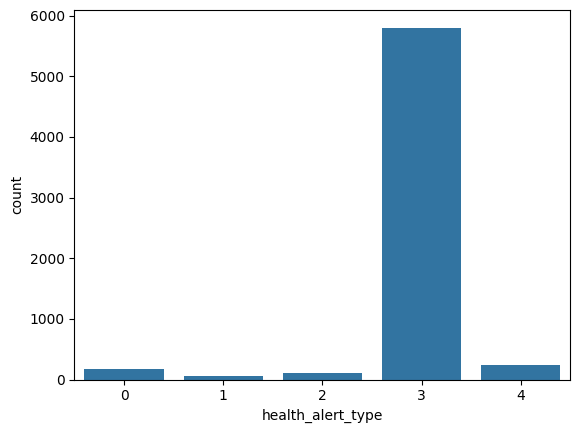

In [37]:
sns.countplot(x='health_alert_type',data=df)

<Axes: >

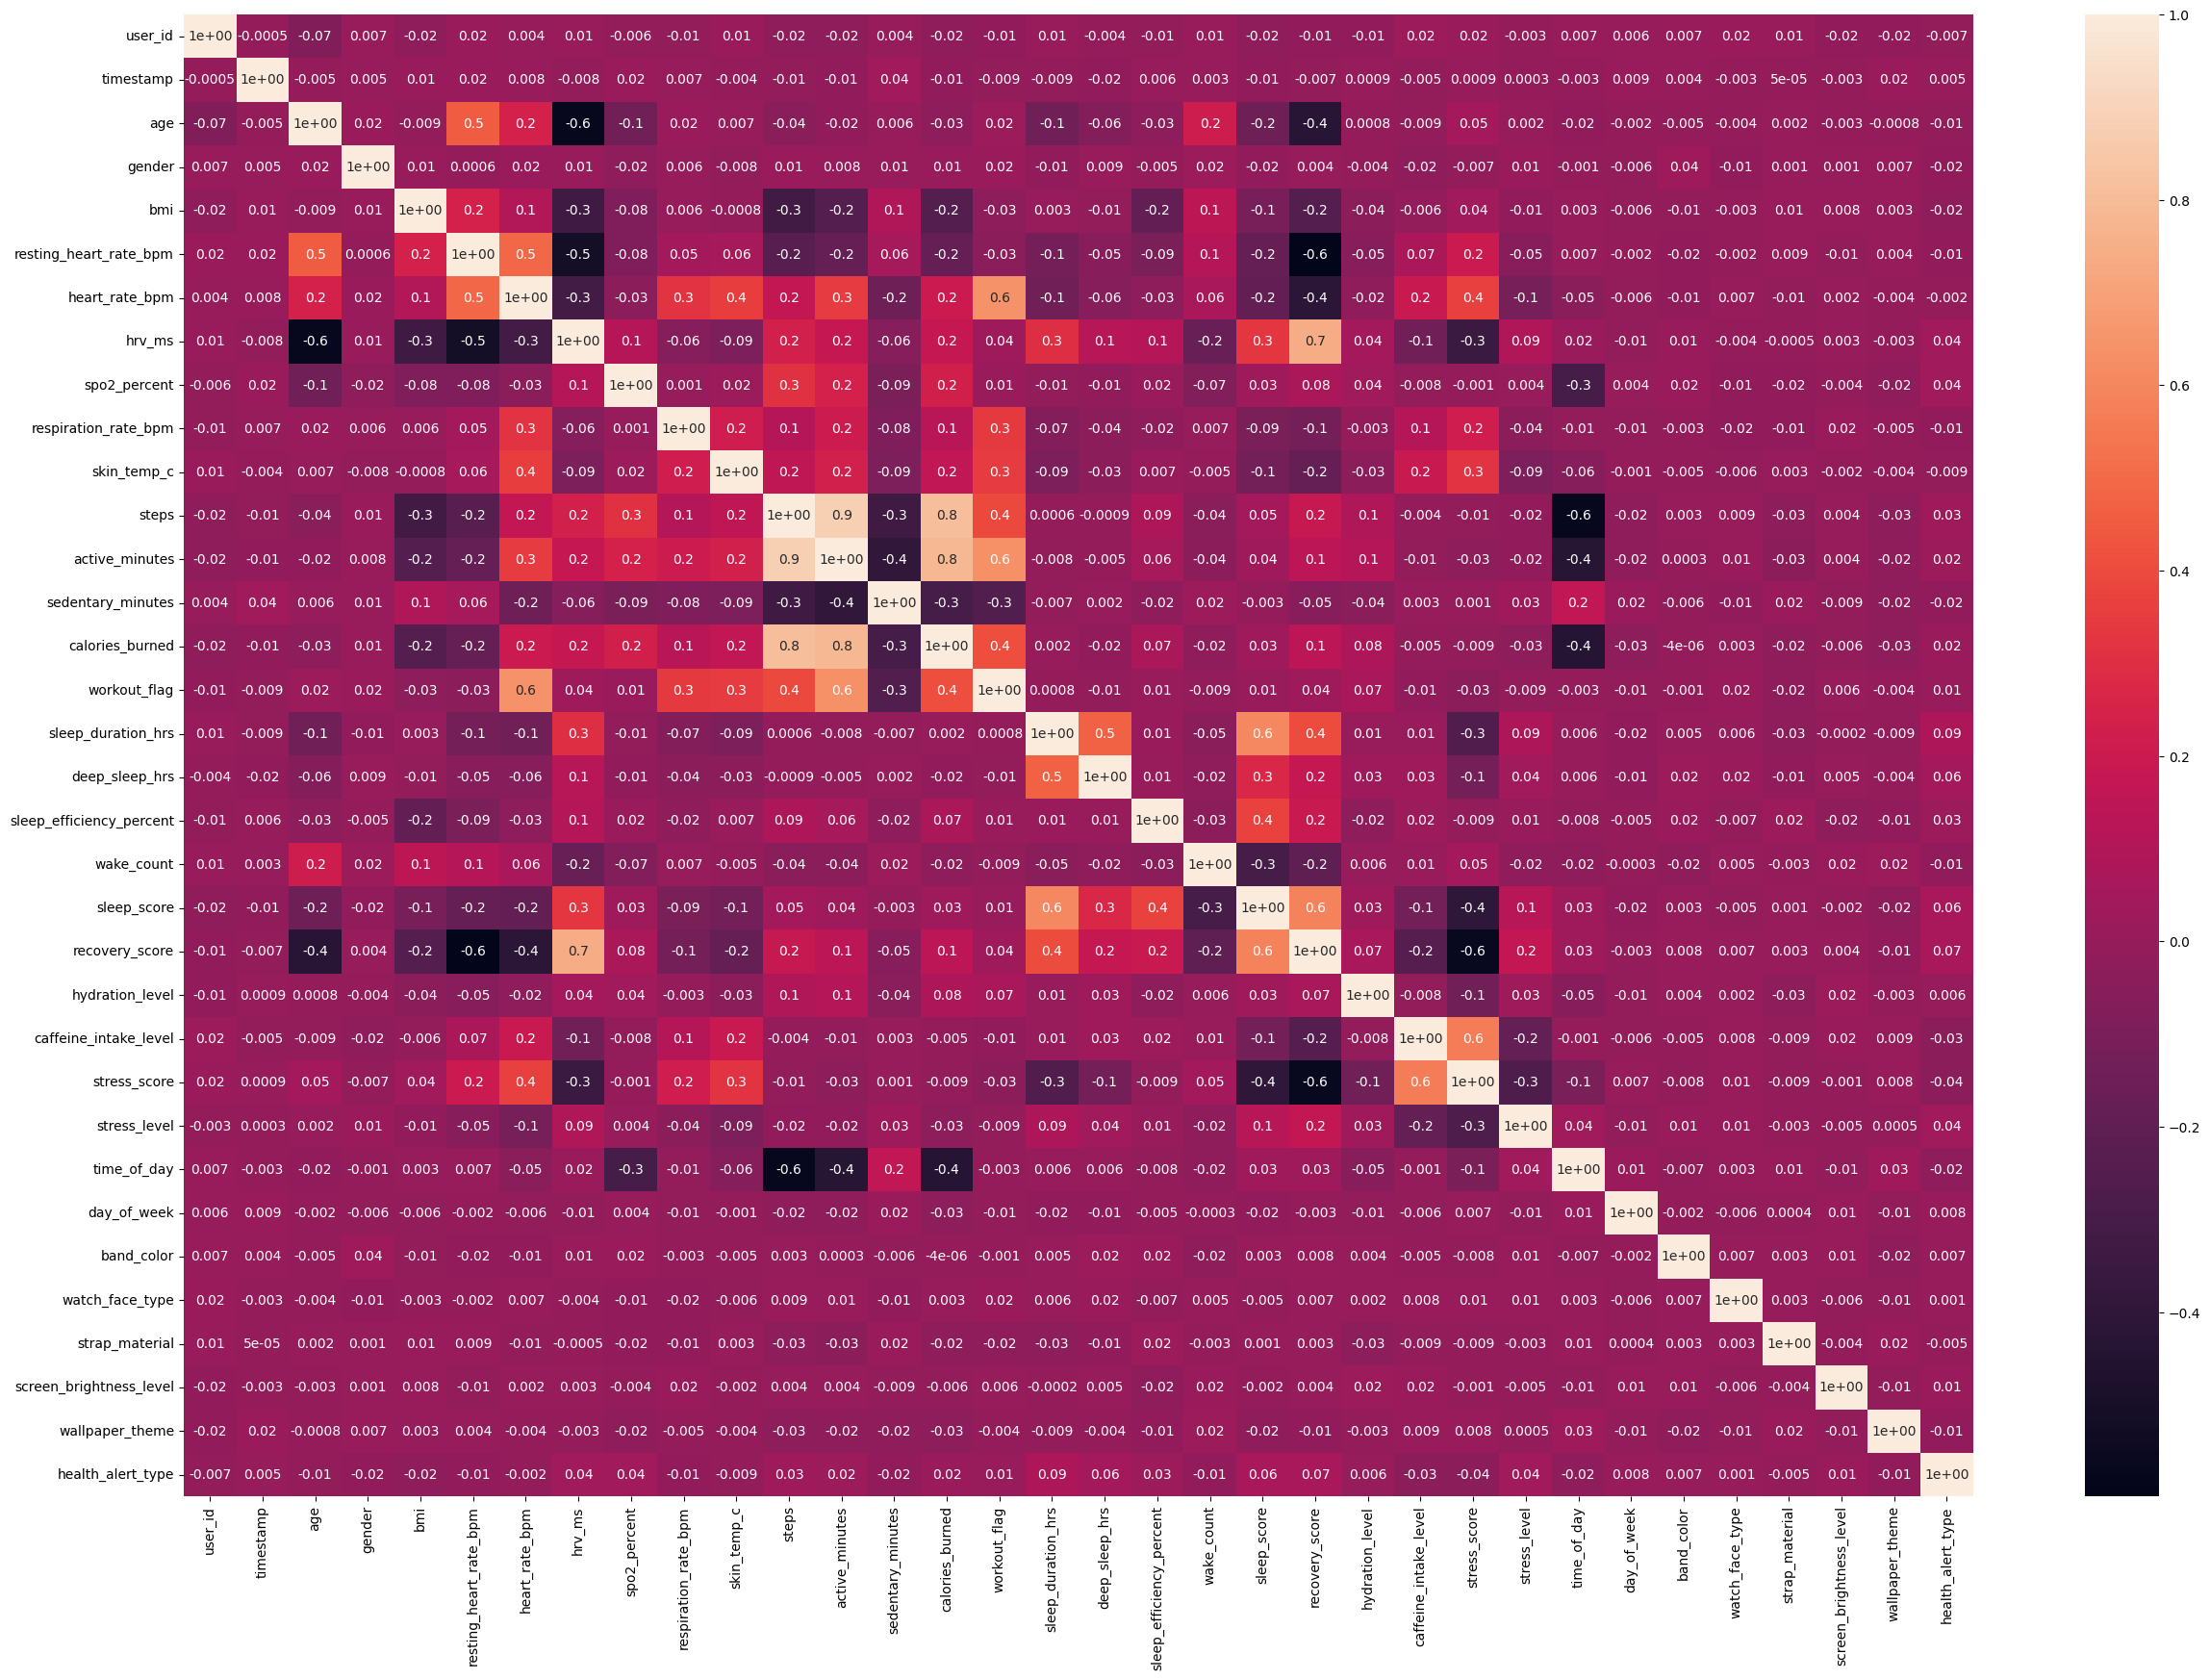

In [38]:
plt.figure(figsize=(30,20))
sns.heatmap(df.corr(),annot=True,fmt='.1')

In [39]:
for i in df.select_dtypes(include='object').columns:
    print(i)
    l=LabelEncoder()
    df[i]=l.fit_transform(df[i])

In [40]:
x=df.drop('health_alert_type',axis=1)
x
y=df['health_alert_type']
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.2,random_state=42)

In [41]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(x_train,y_train)

c:\Users\ahile\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [42]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
y_pred = log_reg.predict(x_test)
accu = accuracy_score(y_test,y_pred)
print('accuracy score:\n',accu)
confusion = confusion_matrix(y_test,y_pred)
print('confusion_matrix :\n',confusion)
classification = classification_report(y_test,y_pred)
print('classification_report:\n',classification)

accuracy score:
 0.9091796875
confusion_matrix :
 [[   0    0    0  141    0]
 [   0    0    0   43    0]
 [   0    0    0   93    0]
 [   0    0    0 4655    0]
 [   0    0    0  188    0]]
classification_report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       141
           1       0.00      0.00      0.00        43
           2       0.00      0.00      0.00        93
           3       0.91      1.00      0.95      4655
           4       0.00      0.00      0.00       188

    accuracy                           0.91      5120
   macro avg       0.18      0.20      0.19      5120
weighted avg       0.83      0.91      0.87      5120



c:\Users\ahile\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ahile\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ahile\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [44]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred1=dt.predict(x_test)
train_score = dt.score(x_train,y_train) # train score
print(train_score)
accu = accuracy_score(y_test,y_pred1)
print('accuracy score:\n',accu)
confusion1 = confusion_matrix(y_test,y_pred1)
print('confusion_matrix :\n',confusion1)
classification1 = classification_report(y_test,y_pred1)
print('classification_report:\n',classification1)



1.0
accuracy score:
 0.804296875
confusion_matrix :
 [[  10    0    3  118   10]
 [   2    1    2   36    2]
 [  13    1    7   62   10]
 [ 209   53   97 4096  200]
 [  10    1    5  168    4]]
classification_report:
               precision    recall  f1-score   support

           0       0.04      0.07      0.05       141
           1       0.02      0.02      0.02        43
           2       0.06      0.08      0.07        93
           3       0.91      0.88      0.90      4655
           4       0.02      0.02      0.02       188

    accuracy                           0.80      5120
   macro avg       0.21      0.21      0.21      5120
weighted avg       0.83      0.80      0.82      5120



In [53]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred12=rf.predict(x_test)
train_score = rf.score(x_train,y_train) # train score
print(train_score)
accu1 = accuracy_score(y_test,y_pred12)
print('accuracy score:\n',accu1)
confusion12 = confusion_matrix(y_test,y_pred12)
print('confusion_matrix :\n',confusion12)
classification12 = classification_report(y_test,y_pred12)
print('classification_report:\n',classification12)

1.0
accuracy score:
 0.909375
confusion_matrix :
 [[   1    0    0  140    0]
 [   0    0    0   43    0]
 [   0    0    0   93    0]
 [   0    0    0 4655    0]
 [   0    0    0  188    0]]
classification_report:
               precision    recall  f1-score   support

           0       1.00      0.01      0.01       141
           1       0.00      0.00      0.00        43
           2       0.00      0.00      0.00        93
           3       0.91      1.00      0.95      4655
           4       0.00      0.00      0.00       188

    accuracy                           0.91      5120
   macro avg       0.38      0.20      0.19      5120
weighted avg       0.85      0.91      0.87      5120



c:\Users\ahile\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ahile\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ahile\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [50]:
from sklearn.ensemble import GradientBoostingClassifier


gradient_boosting_model = GradientBoostingClassifier()


gradient_boosting_model.fit(x_train, y_train)


gradient_boosting_predictions = gradient_boosting_model.predict(x_test)

In [51]:

accu133 = accuracy_score(y_test,gradient_boosting_predictions)
print('accuracy score:\n',accu133)

accuracy score:
 0.8953125


In [54]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
dfs = pca.fit_transform(df)
dfs

array([[-3.90148434e+03,  1.96564916e+03, -2.77331033e+02, ...,
         2.04415315e+01,  7.63641774e+00, -5.11978855e+00],
       [-1.21767566e+03, -7.31635365e+02,  2.31727042e+02, ...,
         8.65195835e+00, -2.69569983e+00, -7.32104164e+00],
       [-5.15214632e+02,  3.25789781e+02,  2.56543213e+02, ...,
         2.39892654e+01,  2.04830940e+01, -1.16399852e+00],
       ...,
       [ 1.84967027e+03, -2.70475845e+03,  8.01253653e+01, ...,
        -1.04016263e+01, -5.74964603e+00,  3.04039541e+00],
       [ 3.98191274e+02, -8.80794212e+02,  1.57568959e+02, ...,
        -2.33917000e+01, -2.11902344e+01, -3.59281874e+00],
       [ 2.12374582e+03,  1.76671975e+03,  2.60664196e+02, ...,
         1.04005658e+01,  1.66010314e+01, -6.17703583e+00]],
      shape=(6400, 10))

In [56]:
pca_df = pd.DataFrame(dfs,columns=[f'PC{i+1}' for i in range(10)])
pca_df['health_alert_type'] = df['health_alert_type']
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,health_alert_type
0,-3901.484341,1965.649162,-277.331033,-112.321535,-19.120924,12.280544,-22.667776,20.441532,7.636418,-5.119789,3.0
1,-1217.675663,-731.635365,231.727042,-78.758315,-71.265081,-2.750521,-5.414222,8.651958,-2.695700,-7.321042,3.0
2,-515.214632,325.789781,256.543213,49.905840,-42.608815,-18.897119,-9.640939,23.989265,20.483094,-1.163999,3.0
3,3153.358405,-2421.425503,49.765813,191.435709,3.774143,3.015307,0.872858,-24.217318,6.882842,-24.070645,3.0
4,1927.469128,1533.825203,209.690264,-131.877126,101.795910,-21.041298,11.622766,-38.535721,-5.951625,8.505931,3.0
...,...,...,...,...,...,...,...,...,...,...,...
6395,1000.966629,-1601.747043,71.235779,-180.090679,-38.398431,-26.964652,12.477401,-18.552110,3.929503,-6.714138,NaN
6396,3675.119736,1390.217216,-87.053519,-35.895256,121.543581,-8.932686,-35.430286,13.538243,-9.424188,-13.411325,3.0
6397,1849.670273,-2704.758450,80.125365,-92.882585,9.981487,43.104912,27.445528,-10.401626,-5.749646,3.040395,3.0
6398,398.191274,-880.794212,157.568959,-258.129842,-49.319749,2.757858,-9.564883,-23.391700,-21.190234,-3.592819,3.0


In [61]:
pca_df.dropna(inplace=True)

In [65]:
x1=pca_df.drop('health_alert_type',axis=1)
x1
y1 = pca_df['health_alert_type']
x_train1,x_test1,y_train1,y_test1 = train_test_split(x1,y1,train_size=0.2,random_state=42)


In [67]:
rff = RandomForestClassifier()
rff.fit(x_train1,y_train1)
y_pred123=rff.predict(x_test1)
train_score = rff.score(x_train1,y_train1) # train score
print(train_score)
accu13333 = accuracy_score(y_test1,y_pred123)
print('accuracy score:\n',accu13333)
confusion12333 = confusion_matrix(y_test1,y_pred123)
print('confusion_matrix :\n',confusion12333)
classification123333 = classification_report(y_test1,y_pred123)
print('classification_report:\n',classification123333)


1.0
accuracy score:
 0.910024154589372
confusion_matrix :
 [[   0    0    0  133    0]
 [   0    0    0   42    0]
 [   0    0    0   91    0]
 [   0    0    0 4521    1]
 [   0    0    0  180    0]]
classification_report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       133
         1.0       0.00      0.00      0.00        42
         2.0       0.00      0.00      0.00        91
         3.0       0.91      1.00      0.95      4522
         4.0       0.00      0.00      0.00       180

    accuracy                           0.91      4968
   macro avg       0.18      0.20      0.19      4968
weighted avg       0.83      0.91      0.87      4968



c:\Users\ahile\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ahile\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ahile\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo